# Homework 04
L. N. Jakubczyk

DATA 71200, Spring 2026


# Simple Poisson Regression Models: Framingham Heart Study

For this homework I'm fitting four simple Poisson regression models on the Framingham data, each with a different single predictor and cigarettes per day as the outcome. CigsPerDay is a count with a lot of zeros (about 51%), so OLS is a bad fit; Poisson GLM uses a log link and multiplicative effects on the expected count. I'm comparing how much deviance each predictor knocks out on its own using deviance-based pseudo R^2 (one minus residual deviance over null deviance), which plays the same comparative role as the coefficient of determination in OLS when ranking simple models.


## How to run this notebook

Open in Jupyter Notebook and run all cells. Dependencies are installed automatically by the first cell.

Model claude-sonnet-4-6 used for boilerplate setup only; analysis and interpretation are my own. 


## 1. Setup and Data Loading

Loading the libraries I need and reading in the dataset. The Excel file has no header row so I have to assign column names manually from the codebook. I also drop any rows with missing values upfront so that all four models are fit on the same sample and the deviance-based pseudo R^2 values are directly comparable.


In [1]:
import subprocess, sys

# install dependencies if missing
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "pandas", "numpy", "matplotlib", "seaborn",
                       "statsmodels", "openpyxl"])

import pandas as pd                                  # data
import numpy as np                                   # numerical
import matplotlib.pyplot as plt                      # plotting
import seaborn as sns                                # heatmap
import statsmodels.api as sm                         # GLM
import statsmodels.formula.api as smf          # formula interface
from IPython.display import display                  # tables in notebook

# the Excel file has no header row, so without header=None pandas would
# treat the first row of data as column names
df = pd.read_excel("04_Framingham-Heart-Study-Brief.xlsx", header=None)

# assign column names from the codebook
df.columns = ["Sex", "Age", "Education", "CigsPerDay", "BMI"]

# drop any row that has at least one missing value
# doing this once here means all four models will run on the same N rows,
# so deviance-based pseudo R^2 is comparable across models
df = df.dropna()
print("Shape (complete cases):", df.shape)
print("(Rows with missing values dropped so regression is on the same N.)")
print("Share with CigsPerDay == 0:", f"{(df['CigsPerDay'] == 0).mean() * 100:.2f}%")
print(df.head(10))

# descriptive stats to check the data looks reasonable before modeling
df.describe()


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Shape (complete cases): (4090, 5)
(Rows with missing values dropped so regression is on the same N.)
Share with CigsPerDay == 0: 50.78%
   Sex  Age  Education  CigsPerDay    BMI
0    1   39        4.0         0.0  26.97
1    0   43        1.0         0.0  27.78
2    0   65        1.0         0.0  19.83
3    0   60        1.0         0.0  27.49
4    0   41        3.0         0.0  22.72
5    1   57        1.0         0.0  28.09
6    0   52        3.0         0.0  26.36
7    0   61        2.0         0.0  24.79
8    1   45        4.0         0.0  28.40
9    0   39        1.0         0.0  20.99


,Sex,Age,Education,CigsPerDay,BMI
count,4090.000000,4090.000000,4090.000000,4090.000000,4090.000000
mean,0.427873,49.545477,1.979218,9.050856,25.776257
std,0.494831,8.559061,1.020124,11.935912,4.084651
min,0.000000,32.000000,1.000000,0.000000,15.540000
25%,0.000000,42.000000,1.000000,0.000000,23.052500
50%,0.000000,49.000000,2.000000,0.000000,25.380000
75%,1.000000,56.000000,3.000000,20.000000,27.990000
max,1.000000,70.000000,4.000000,70.000000,56.800000


## 2. Correlation Matrix of the Five Variables

Before running the regressions I want to look at the pairwise correlations. In OLS simple regression, the coefficient of determination equals the squared Pearson correlation with the outcome, so the matrix is a rough preview of which predictor lines up with CigsPerDay. Poisson uses a different measure (deviance-based pseudo R^2), but the correlations still help compare the four models.


Correlation matrix (Pearson):


,Sex,Age,Education,CigsPerDay,BMI
Sex,1.000,-0.028,0.016,0.320,0.081
Age,-0.028,1.000,-0.164,-0.193,0.136
Education,0.016,-0.164,1.000,0.008,-0.138
CigsPerDay,0.320,-0.193,0.008,1.000,-0.090
BMI,0.081,0.136,-0.138,-0.090,1.000


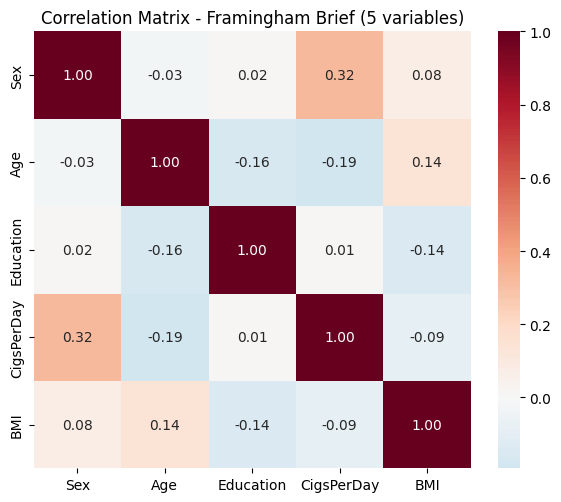

In [2]:
# df.corr() computes pairwise Pearson correlations for all numeric columns
corr = df.corr()
print("Correlation matrix (Pearson):")
display(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,       # print the correlation value in each cell
    fmt=".2f",        # two decimal places
    cmap="RdBu_r",    # blue = positive correlation, red = negative
    center=0,         # anchor the color scale at zero so white = no correlation
    square=True,
    ax=ax,
)
plt.title("Correlation Matrix - Framingham Brief (5 variables)")
plt.tight_layout()
plt.show()


## 3. Simple Poisson Regression Models

Each model is statsmodels GLM with Poisson family and the default log link (expected count = exp(linear predictor)). exp(coef) is the factor change in the expected count per one-unit increase in predictor (or male vs female for Sex).

Proportional deviance reduction is one minus (residual deviance divided by null deviance). That is the reduction in deviance relative to an intercept-only model. That is what I report below as deviance-based pseudo R^2.

I define y once; each model adds one predictor.


In [3]:
# outcome variable, same for all four models
y = df["CigsPerDay"]


def pseudo_r2_deviance(res):
    # 1 - residual_deviance / null_deviance; same comparative role as OLS when ranking simple models
    return 1.0 - res.deviance / res.null_deviance


def fit_poisson(formula):
    return smf.glm(formula, data=df, family=sm.families.Poisson()).fit()


In [4]:
# Model 1: Sex (0=Female, 1=Male)
# double brackets give a 2D frame (kept for symmetry with HW02); formula uses df columns
X1 = df[["Sex"]]
res1 = fit_poisson("CigsPerDay ~ Sex")
# intercept is log(expected count) when Sex=0 (females); coef(Sex) is log rate ratio male vs female
print("Model 1: CigsPerDay ~ Sex")
print(res1.summary())
print(f"Pseudo R^2 (deviance): {pseudo_r2_deviance(res1):.6f}")
print(f"exp(coef Sex) = IRR (male vs female): {np.exp(res1.params['Sex']):.4f}")
print()


Model 1: CigsPerDay ~ Sex
                 Generalized Linear Model Regression Results                  
Dep. Variable:             CigsPerDay   No. Observations:                 4090
Model:                            GLM   Df Residuals:                     4088
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -34269.
Date:                Wed, 15 Apr 2026   Deviance:                       59442.
Time:                        16:38:01   Pearson chi2:                 5.77e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.7970
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.7488     

In [5]:
# Model 2: Age (continuous, 32-70)
X2 = df[["Age"]]
res2 = fit_poisson("CigsPerDay ~ Age")
# negative coef would mean older participants have lower expected count holding nothing else
print("Model 2: CigsPerDay ~ Age")
print(res2.summary())
print(f"Pseudo R^2 (deviance): {pseudo_r2_deviance(res2):.6f}")
print(f"exp(coef Age) = factor per +1 year: {np.exp(res2.params['Age']):.4f}")
print()


Model 2: CigsPerDay ~ Age
                 Generalized Linear Model Regression Results                  
Dep. Variable:             CigsPerDay   No. Observations:                 4090
Model:                            GLM   Df Residuals:                     4088
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -36295.
Date:                Wed, 15 Apr 2026   Deviance:                       63493.
Time:                        16:38:01   Pearson chi2:                 6.37e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4532
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.7081     

In [6]:
# Model 3: Education (ordinal 1-4, where 1=lowest and 4=highest)
# treating it as continuous here, same simplification as HW02 OLS
X3 = df[["Education"]]
res3 = fit_poisson("CigsPerDay ~ Education")
print("Model 3: CigsPerDay ~ Education")
print(res3.summary())
print(f"Pseudo R^2 (deviance): {pseudo_r2_deviance(res3):.6f}")
print()


Model 3: CigsPerDay ~ Education
                 Generalized Linear Model Regression Results                  
Dep. Variable:             CigsPerDay   No. Observations:                 4090
Model:                            GLM   Df Residuals:                     4088
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -37528.
Date:                Wed, 15 Apr 2026   Deviance:                       65958.
Time:                        16:38:01   Pearson chi2:                 6.44e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001086
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.181

In [7]:
# Model 4: BMI (continuous)
X4 = df[["BMI"]]
res4 = fit_poisson("CigsPerDay ~ BMI")
print("Model 4: CigsPerDay ~ BMI")
print(res4.summary())
print(f"Pseudo R^2 (deviance): {pseudo_r2_deviance(res4):.6f}")
print()


Model 4: CigsPerDay ~ BMI
                 Generalized Linear Model Regression Results                  
Dep. Variable:             CigsPerDay   No. Observations:                 4090
Model:                            GLM   Df Residuals:                     4088
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -37257.
Date:                Wed, 15 Apr 2026   Deviance:                       65418.
Time:                        16:38:01   Pearson chi2:                 6.52e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1247
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9910     

## 4. Comparison Table: deviance-based pseudo R^2 for each model

Putting all four deviance-based pseudo R^2 values in one table so I can rank the models. The numbers won't match the OLS coefficient of determination from HW02, but the same order shows up: Sex first, then Age, then BMI, Education last.


In [8]:
# deviance-based pseudo R^2 from each fitted model
model_rows = [
    ("CigsPerDay ~ Sex", pseudo_r2_deviance(res1)),
    ("CigsPerDay ~ Age", pseudo_r2_deviance(res2)),
    ("CigsPerDay ~ Education", pseudo_r2_deviance(res3)),
    ("CigsPerDay ~ BMI", pseudo_r2_deviance(res4)),
]

dev_table = pd.DataFrame(model_rows, columns=["Model", "Deviance_explained"])
dev_table["Explained (%)"] = [f"{r * 100:.2f}%" for r in dev_table["Deviance_explained"]]
# sort descending so the best model is at the top
dev_table = dev_table.sort_values("Deviance_explained", ascending=False).reset_index(drop=True)
display(dev_table)

best = dev_table.iloc[0]
print(
    f"Best single-predictor model: {best['Model']} "
    f"(pseudo R^2 = {best['Deviance_explained']:.6f}, {best['Explained (%)']})"
)


,Model,Deviance_explained,Explained (%)
0,CigsPerDay ~ Sex,0.098856,9.89%
1,CigsPerDay ~ Age,0.037436,3.74%
2,CigsPerDay ~ BMI,0.008260,0.83%
3,CigsPerDay ~ Education,0.000067,0.01%


Best single-predictor model: CigsPerDay ~ Sex (pseudo R^2 = 0.098856, 9.89%)


## 4b. Bar chart (same values as the table)

Quick visual of the comparison table: horizontal bars, worst model at the bottom.

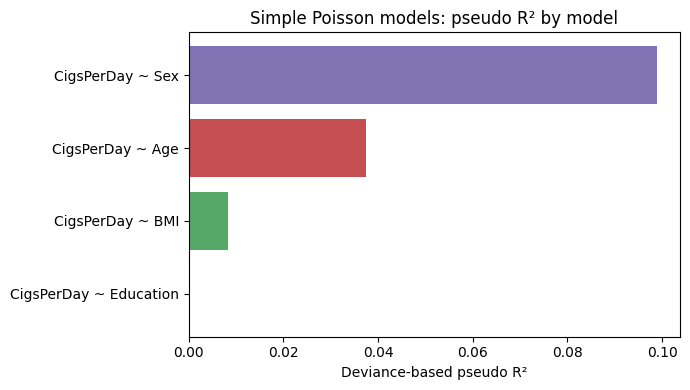

In [9]:
# same rows as dev_table, sorted worst at bottom for barh (matches build_hw04_writeup.py)
labels = list(dev_table["Model"])[::-1]
vals = list(dev_table["Deviance_explained"])[::-1]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(labels, vals, color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"])
ax.set_xlabel("Deviance-based pseudo R^2")
ax.set_title("Simple Poisson models: pseudo R^2 by model")
plt.tight_layout()
plt.show()

## 5. Distribution of the outcome

Histogram of CigsPerDay: lots of zeros and a long right tail, which is why the assignment moved off Gaussian OLS for this variable.


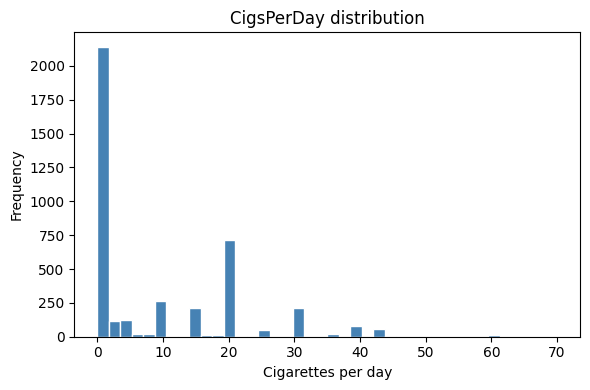

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["CigsPerDay"], bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Cigarettes per day")
ax.set_ylabel("Frequency")
ax.set_title("CigsPerDay distribution")
plt.tight_layout()
plt.show()


## 6. Interpretation

Sex carries the largest deviance-based pseudo R^2 (about 0.10 on the deviance scale), then Age (about 0.04), BMI (about 0.01), and Education is basically flat. The correlation matrix lined up the same way (Sex had the largest absolute correlation with CigsPerDay).

In these Poisson models, exp(coef) is a rate ratio on the expected count: males have a much higher expected count than females (about 2.3 times in the Sex-only model). Age and BMI are negative on the log scale in these simple fits. Education barely moves the needle; with a cohort enrolled starting in the late 1940s, the modern education-smoking gradient is not really visible here, which fits a near-zero coefficient and fit.

Framingham started in 1948; the Sex coefficient is partly period gender norms around smoking, not biology.

A plain Poisson model expects the variance of CigsPerDay to match its mean at each predicted level. In real data like this, the spread is usually wider than that (overdispersion), and a big pile of zeros can mean “extra” non-smokers on top of what a simple Poisson count story would predict. Statisticians often switch to a negative binomial model to allow that extra spread, or a zero-inflated model when there are more zeros than a single Poisson count can explain. This assignment only required Poisson, so I stopped there.

The uniformly modest fit across all four models matches HW02: these are distal demographics, and smoking behavior has drivers that are not in this short variable list.
